# 02 — The baseline ladder and the Kalman result

Question: after removing trend + seasonality (fit on training data only, per fold), is there
any predictability left beyond persistence-style baselines?

Answer, in three steps:
1. Damped persistence beats naive persistence and climatology everywhere.
2. Per-basin ridge on 5 own lags beats damped persistence at 1–4 months (+2–5%, DM p<1e-4).
3. A 3-parameter Kalman filter (AR(1) state + observation noise) beats the ridge at **every**
   lead — most of the "skill above persistence" is optimal filtering of GRACE noise.

Results are produced by `scripts/run_phase2_baselines.py` and `scripts/run_kalman_baseline.py`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from gracefc.models import rmse

summary = pd.read_csv(ROOT / "results/phase2_baseline_summary.csv")
summary.head()

,model,horizon,rmse_cm,mae_cm,r,n,rmse_std,skill_vs_damped
0,ridge_own_perbasin,1,5.135642,2.637832,0.863267,19656,1.054946,0.028490
1,ridge_own_lags,1,5.650366,2.793015,0.841629,19656,1.067509,0.005215
2,ridge_own_plus_indices,1,5.707759,2.809991,0.838613,19656,1.068632,0.003120
3,damped_persistence_rho,1,5.310725,2.702274,0.854556,19656,1.070303,0.000000
4,damped_persistence_reg,1,5.278551,2.708794,0.856987,19656,1.077804,-0.014066


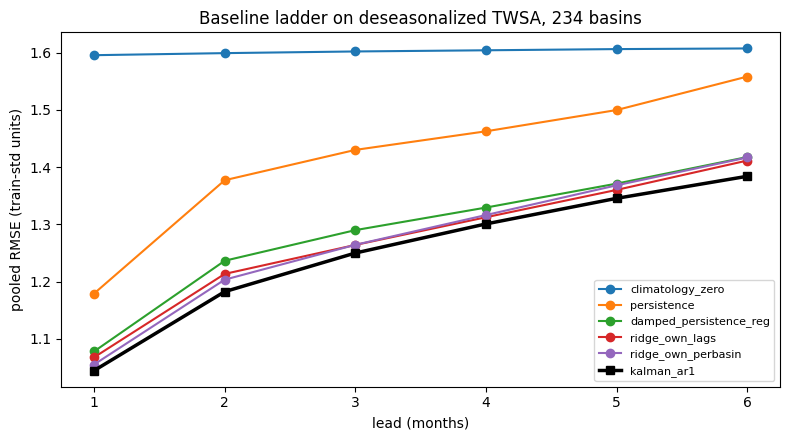

In [2]:
# Ladder in standardized units: lower is better; damped persistence is the reference
order = ["climatology_zero", "persistence", "damped_persistence_reg",
         "ridge_own_lags", "ridge_own_perbasin"]
fig, ax = plt.subplots(figsize=(8, 4.5))
for m in order:
    sub = summary[summary["model"] == m].sort_values("horizon")
    ax.plot(sub["horizon"], sub["rmse_std"], marker="o", label=m)
kal = pd.read_csv(ROOT / "results/kalman_predictions.csv", parse_dates=["target_date"])
kr = kal.groupby("horizon").apply(lambda g: rmse(g["target"].values, g["pred"].values), include_groups=False)
ax.plot(kr.index, kr.values, marker="s", lw=2.5, color="black", label="kalman_ar1")
ax.set_xlabel("lead (months)"); ax.set_ylabel("pooled RMSE (train-std units)")
ax.set_title("Baseline ladder on deseasonalized TWSA, 234 basins")
ax.legend(fontsize=8)
plt.tight_layout()

In [3]:
# Skill of each model vs damped persistence, by lead
piv = summary.pivot(index="model", columns="horizon", values="rmse_std")
damped = piv.loc["damped_persistence_reg"]
skill = (1 - (piv / damped) ** 2) * 100
skill.loc["kalman_ar1"] = (1 - (kr / damped) ** 2) * 100
skill.round(2).sort_values(1, ascending=False)

horizon,1,2,3,4,5,6
model,,,,,,
kalman_ar1,6.12,8.55,6.11,4.26,3.72,4.69
ridge_own_perbasin,4.20,5.28,3.94,1.96,0.43,0.11
ridge_own_lags,1.90,3.69,3.97,2.53,1.60,0.87
ridge_own_plus_indices,1.69,3.42,4.06,2.63,1.62,0.71
damped_persistence_rho,1.39,-0.42,-5.47,-10.31,-10.10,-7.98
damped_persistence_reg,0.00,0.00,0.00,0.00,0.00,0.00
persistence,-19.67,-24.07,-22.93,-21.07,-19.64,-20.83
climatology_zero,-119.22,-67.35,-54.30,-45.65,-37.25,-28.57


**Why the Kalman filter wins (errors-in-variables in one sentence):** damped persistence decays
the *observed* current month, noise included; the Kalman filter first estimates how much of the
current observation is signal, then decays that — and with GRACE observation noise at 1–2 cm,
that distinction is worth ~5% at short leads and persists to lead 6.

**Paper implication:** any ML/graph model claiming skill on deseasonalized TWSA must beat this
3-parameter filter, not just persistence — a bar most of the literature has not applied.